# Tutorial 09 — Dantzig-Wolfe Decomposition and Column Generation

> **What if the problem has far too many decision variables to write down?**

## Where we are

```text
ED → UC → DC-OPF → AC-OPF → SOCP → multi-period → uncertainty
         → Benders → >> column generation << → capstone
                      ^
                      YOU ARE HERE
```

## The opposite of Benders

| | Benders | Dantzig-Wolfe / column generation |
|---|---|---|
| master starts with | too **few** constraints | too **few** variables |
| iteratively adds | **cuts** (constraints) | **columns** (variables) |
| subproblem returns | a dual solution | a new column |
| exploits | few complicating *variables* | block-angular structure |
| asks | "is my approximation of $Q(y)$ good enough?" | "does a better pattern exist?" |

Same bound-squeezing idea, entered from the other side.

## Learning objectives

1. Represent a generator's whole day as a single **column**;
2. write the restricted master and read its dual prices;
3. derive the **reduced cost** and see why the pricing problem is itself an
   optimization problem;
4. implement the loop and verify it against a monolithic MILP;
5. explain why column generation gives an **LP** answer, and what it takes to
   get an integer one.

## The claim this notebook tests

> "Column generation produces an integer solution."

It does not, and the notebook measures how far off the integer recovery is.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

from psopt_course.config import fast_mode, scaled, set_seed
from psopt_course.decomposition import BoundHistory
from psopt_course.metrics import certified_interval
from psopt_course.plotting import COLORS, use_course_style
from psopt_course.solvers import solve

use_course_style()
set_seed()
print(f"reduced (fast) configuration: {fast_mode()}")

reduced (fast) configuration: False


## 1. The problem, and the reformulation

Unit commitment again. The **compact** formulation has variables
$u_{g,t}, v_{g,t}, p_{g,t}$ — Tutorial 02's model.

Dantzig-Wolfe reformulates it. Let $X_g$ be the set of **all feasible daily
schedules** of generator $g$: every combination of on/off, start-ups and
output that respects its own constraints. Then a dispatch is a choice of one
schedule per generator, and by convexification

$$
\begin{aligned}
\min \quad & \sum_g \sum_{k \in X_g} c_{gk}\,\lambda_{gk} \\
\text{s.t.} \quad
 & \sum_g \sum_k p^t_{gk}\,\lambda_{gk} = D_t \quad \forall t && [\pi_t] \\
 & \sum_{k \in X_g} \lambda_{gk} = 1 \quad \forall g && [\sigma_g] \\
 & \lambda_{gk} \ge 0
\end{aligned}
$$

Two constraint families and they play different roles:

* the **linking** constraint (demand) couples the generators — it is what
  stops them being solved separately;
* the **convexity** constraint says each generator picks exactly one schedule
  (or a convex combination of schedules).

The catch: $|X_g|$ is astronomical. Six periods already give $2^6$ commitment
patterns per generator before output is chosen. Column generation never
enumerates them; it generates the few that matter.

In [2]:
T = scaled(full=6, fast=4)
DEMAND = np.array([60.0, 75.0, 110.0, 130.0, 95.0, 70.0])[:T]
GENS = [
    {"name": "coal", "pmin": 20.0, "pmax": 70.0, "c1": 25.0,
     "start": 400.0, "noload": 60.0, "minup": 3},
    {"name": "gas", "pmin": 10.0, "pmax": 60.0, "c1": 55.0,
     "start": 120.0, "noload": 20.0, "minup": 2},
    {"name": "peak", "pmin": 5.0, "pmax": 40.0, "c1": 95.0,
     "start": 40.0, "noload": 5.0, "minup": 1},
]
display(pd.DataFrame(GENS).set_index("name"))
print(f"{T} periods, demand {DEMAND.tolist()} MW")
print(f"commitment patterns per generator: 2^{T} = {2**T}")
print(f"combinations across {len(GENS)} generators: {(2**T)**len(GENS):,}")

,pmin,pmax,c1,start,noload,minup
name,,,,,,
coal,20.0,70.0,25.0,400.0,60.0,3
gas,10.0,60.0,55.0,120.0,20.0,2
peak,5.0,40.0,95.0,40.0,5.0,1


6 periods, demand [60.0, 75.0, 110.0, 130.0, 95.0, 70.0] MW
commitment patterns per generator: 2^6 = 64
combinations across 3 generators: 262,144


## 2. Ground truth first

In [3]:
def monolithic(relax=False):
    """The compact unit-commitment formulation from Tutorial 02, plus min up-time."""
    m = pyo.ConcreteModel(name="UC (compact)")
    m.G = pyo.Set(initialize=range(len(GENS)))
    m.T = pyo.Set(initialize=range(T), ordered=True)
    m.u = pyo.Var(m.G, m.T, domain=pyo.UnitInterval if relax else pyo.Binary)
    m.v = pyo.Var(m.G, m.T, domain=pyo.NonNegativeReals)
    m.p = pyo.Var(m.G, m.T, domain=pyo.NonNegativeReals)

    m.dem = pyo.Constraint(m.T, rule=lambda m, t: sum(m.p[g, t] for g in m.G) == DEMAND[t])
    m.lo = pyo.Constraint(m.G, m.T,
                          rule=lambda m, g, t: m.p[g, t] >= GENS[g]["pmin"] * m.u[g, t])
    m.hi = pyo.Constraint(m.G, m.T,
                          rule=lambda m, g, t: m.p[g, t] <= GENS[g]["pmax"] * m.u[g, t])

    @m.Constraint(m.G, m.T)
    def startup(m, g, t):
        if t == m.T.first():
            return m.v[g, t] >= m.u[g, t]
        return m.v[g, t] >= m.u[g, t] - m.u[g, m.T.prev(t)]

    @m.Constraint(m.G, m.T)
    def minup(m, g, t):
        length = GENS[g]["minup"]
        if t + length > T:
            return pyo.Constraint.Skip
        return sum(m.u[g, tt] for tt in range(t, t + length)) >= length * m.v[g, t]

    m.obj = pyo.Objective(
        expr=sum(
            GENS[g]["c1"] * m.p[g, t] + GENS[g]["noload"] * m.u[g, t]
            + GENS[g]["start"] * m.v[g, t]
            for g in m.G for t in m.T
        )
    )
    return m


milp_record = solve(monolithic(), "MILP")
lp_record = solve(monolithic(relax=True), "LP")
print(f"MILP optimum      : {milp_record.objective:,.4f}   <- what we must reproduce")
print(f"LP relaxation     : {lp_record.objective:,.4f}   <- a lower bound")
print(f"integrality gap   : "
      f"{(milp_record.objective - lp_record.objective) / milp_record.objective:.3%}")

MILP optimum      : 18,510.0000   <- what we must reproduce
LP relaxation     : 18,314.7619   <- a lower bound
integrality gap   : 1.055%


## 3. The restricted master

Start with a handful of columns and see what the prices say.

### Artificial variables

With two starting columns per generator — flat out, and off — no convex
combination matches a varying demand, so the first master is **infeasible**.
An infeasible LP has no duals, and without duals there is nothing to price
with: the method cannot start.

The standard remedy is a penalised artificial variable on each linking
constraint. It buys feasibility at an enormous price, and real columns drive
it to zero.

In [4]:
BIG_M = 1e5


def make_column(u, spec):
    """Turn a commitment vector into a column: output, cost, start-ups."""
    u = np.asarray(u, dtype=float)
    p = u * spec["pmax"]
    starts = sum(max(u[t] - (u[t - 1] if t else 0.0), 0.0) for t in range(len(u)))
    cost = float(
        spec["c1"] * p.sum() + spec["noload"] * u.sum() + spec["start"] * starts
    )
    return {"u": u, "p": p, "cost": cost}


columns = {
    g: [make_column(np.ones(T), spec), make_column(np.zeros(T), spec)]
    for g, spec in enumerate(GENS)
}
print(f"starting columns: {sum(len(v) for v in columns.values())} "
      f"({len(columns[0])} per generator)")


def restricted_master(columns):
    m = pyo.ConcreteModel(name="restricted master")
    m.G = pyo.Set(initialize=range(len(GENS)))
    m.T = pyo.Set(initialize=range(T))
    m.K = pyo.Set(initialize=[(g, k) for g in columns for k in range(len(columns[g]))],
                  dimen=2)
    m.lam = pyo.Var(m.K, domain=pyo.NonNegativeReals, bounds=(0, 1))
    m.slack_up = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.slack_dn = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    @m.Constraint(m.T)
    def demand(m, t):
        """The LINKING constraint. Its dual is the price of energy at time t."""
        return (
            sum(columns[g][k]["p"][t] * m.lam[g, k] for (g, k) in m.K)
            + m.slack_up[t] - m.slack_dn[t] == DEMAND[t]
        )

    @m.Constraint(m.G)
    def convexity(m, g):
        """Each generator uses exactly one schedule. Its dual is a fixed rebate."""
        return sum(m.lam[g, k] for k in range(len(columns[g]))) == 1

    m.obj = pyo.Objective(
        expr=sum(columns[g][k]["cost"] * m.lam[g, k] for (g, k) in m.K)
        + BIG_M * sum(m.slack_up[t] + m.slack_dn[t] for t in m.T)
    )
    return m

starting columns: 6 (2 per generator)


## 4. Reduced cost and the pricing problem

In the simplex method, a non-basic variable improves the objective when its
**reduced cost** is negative. Here the "variables" are schedules, and the
reduced cost of schedule $k$ of generator $g$ is

$$\bar{c}_{gk} = \underbrace{c_{gk}}_{\text{its own cost}}
  \;-\; \underbrace{\sum_t \pi_t\,p^t_{gk}}_{\text{revenue at the current prices}}
  \;-\; \underbrace{\sigma_g}_{\text{convexity dual}}$$

We cannot compute this for every schedule — there are too many. So we
**minimise** it instead:

$$\min_{k \in X_g} \bar{c}_{gk}
 = \min_{(u,v,p) \in X_g}
   \Big[\sum_t \big(c_g p_t + n_g u_t + s_g v_t - \pi_t p_t\big)\Big] - \sigma_g$$

That is the **pricing problem**: a small optimization problem, one per
generator, over that generator's *own* constraints only. It is a
single-machine unit commitment at the current prices — and it is exactly the
structure that the compact formulation buried.

If the minimum reduced cost is $\ge 0$, no schedule can improve the master and
the LP is solved. Otherwise the minimiser **is** the new column.

In [5]:
def pricing(g, prices, sigma):
    """Best schedule for generator g at the current prices."""
    spec = GENS[g]
    m = pyo.ConcreteModel(name=f"pricing[{spec['name']}]")
    m.T = pyo.Set(initialize=range(T), ordered=True)
    m.u = pyo.Var(m.T, domain=pyo.Binary)
    m.v = pyo.Var(m.T, domain=pyo.NonNegativeReals)
    m.p = pyo.Var(m.T, domain=pyo.NonNegativeReals)

    m.lo = pyo.Constraint(m.T, rule=lambda m, t: m.p[t] >= spec["pmin"] * m.u[t])
    m.hi = pyo.Constraint(m.T, rule=lambda m, t: m.p[t] <= spec["pmax"] * m.u[t])

    @m.Constraint(m.T)
    def startup(m, t):
        if t == m.T.first():
            return m.v[t] >= m.u[t]
        return m.v[t] >= m.u[t] - m.u[m.T.prev(t)]

    @m.Constraint(m.T)
    def minup(m, t):
        length = spec["minup"]
        if t + length > T:
            return pyo.Constraint.Skip
        return sum(m.u[tt] for tt in range(t, t + length)) >= length * m.v[t]

    m.obj = pyo.Objective(
        expr=sum(
            spec["c1"] * m.p[t] + spec["noload"] * m.u[t] + spec["start"] * m.v[t]
            - prices[t] * m.p[t]
            for t in m.T
        )
        - sigma
    )
    record = solve(m, "MILP")
    u = np.array([round(pyo.value(m.u[t])) for t in m.T], dtype=float)
    p = np.array([pyo.value(m.p[t]) for t in m.T])
    starts = sum(max(u[t] - (u[t - 1] if t else 0.0), 0.0) for t in range(T))
    cost = float(spec["c1"] * p.sum() + spec["noload"] * u.sum() + spec["start"] * starts)
    return {"u": u, "p": p, "cost": cost}, record.objective

## 5. The loop

In [6]:
history = BoundHistory(name="column generation", enforce_monotone=False)
trace = []

for iteration in range(1, 31):
    master = restricted_master(columns)
    master_record = solve(master, "LP", duals=True)
    if not master_record.ok:
        print(f"  master {master_record.termination} — cannot price without duals")
        break

    prices = np.array([master.dual[master.demand[t]] for t in range(T)])
    sigmas = {g: master.dual[master.convexity[g]] for g in range(len(GENS))}
    artificial = sum(
        pyo.value(master.slack_up[t]) + pyo.value(master.slack_dn[t]) for t in range(T)
    )

    added, best_reduced = 0, 0.0
    for g in range(len(GENS)):
        column, reduced = pricing(g, prices, sigmas[g])
        if reduced < -1e-6:
            columns[g].append(column)
            added += 1
            best_reduced = min(best_reduced, reduced)

    trace.append({
        "iteration": iteration, "master objective": master_record.objective,
        "columns": sum(len(v) for v in columns.values()),
        "added": added, "best reduced cost": best_reduced,
        "artificial": artificial,
    })
    print(f"  it {iteration:2d}  RMP = {master_record.objective:12,.4f}  "
          f"columns = {trace[-1]['columns']:3d}  added = {added}  "
          f"min reduced cost = {best_reduced:+.4f}  artificial = {artificial:.2f}")

    if added == 0:
        print("\n  CONVERGED: no schedule has negative reduced cost, so the LP")
        print("  over ALL columns is solved — without ever enumerating them.")
        break

trace = pd.DataFrame(trace).set_index("iteration")

  it  1  RMP = 13,012,930.0000  columns =   9  added = 3  min reduced cost = -20994170.0000  artificial = 130.00


  it  2  RMP = 5,017,980.0000  columns =  12  added = 3  min reduced cost = -14003220.0000  artificial = 50.00


  it  3  RMP = 2,517,806.6667  columns =  15  added = 3  min reduced cost = -11997616.6667  artificial = 25.00


  it  4  RMP = 1,518,321.0000  columns =  18  added = 3  min reduced cost = -13977282.0000  artificial = 15.00


  it  5  RMP =  19,707.7381  columns =  21  added = 3  min reduced cost = -3520.0000  artificial = 0.00


  it  6  RMP =  19,606.0417  columns =  23  added = 2  min reduced cost = -4978.3333  artificial = 0.00


  it  7  RMP =  19,299.1161  columns =  25  added = 2  min reduced cost = -1973.1863  artificial = 0.00


  it  8  RMP =  18,817.9591  columns =  27  added = 2  min reduced cost = -2463.3333  artificial = 0.00


  it  9  RMP =  18,316.1508  columns =  29  added = 2  min reduced cost = -1516.6667  artificial = 0.00


  it 10  RMP =  18,314.7619  columns =  29  added = 0  min reduced cost = +0.0000  artificial = 0.00

  CONVERGED: no schedule has negative reduced cost, so the LP
  over ALL columns is solved — without ever enumerating them.


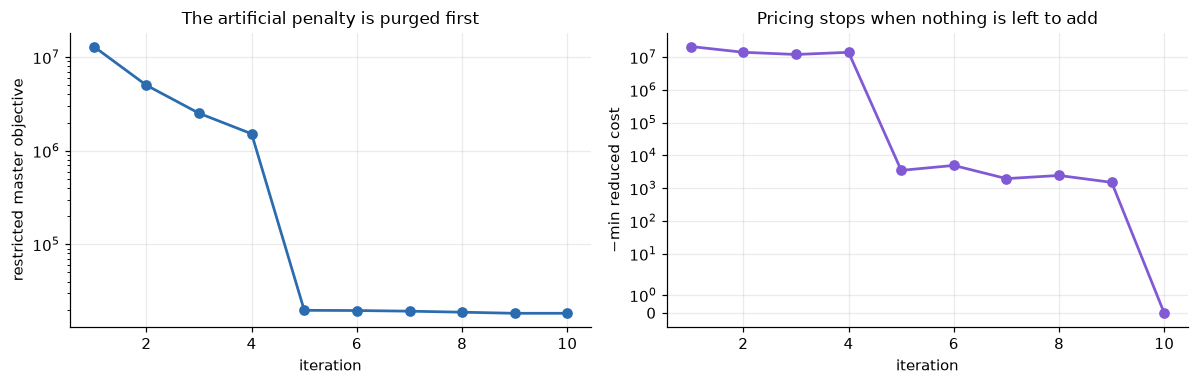

column-generation LP bound : 18,314.7619
LP relaxation of the compact formulation: 18,314.7619
MILP optimum               : 18,510.0000

columns generated: 29 out of at least 192 possible commitment patterns


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].semilogy(trace.index, trace["master objective"], "o-", color=COLORS["feasible"])
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("restricted master objective")
axes[0].set_title("The artificial penalty is purged first")
axes[1].plot(trace.index, -trace["best reduced cost"], "o-", color=COLORS["accent"])
axes[1].set_yscale("symlog")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("$-$min reduced cost")
axes[1].set_title("Pricing stops when nothing is left to add")
fig.tight_layout()
plt.show()

final_master = restricted_master(columns)
cg_record = solve(final_master, "LP")
print(f"column-generation LP bound : {cg_record.objective:,.4f}")
print(f"LP relaxation of the compact formulation: {lp_record.objective:,.4f}")
print(f"MILP optimum               : {milp_record.objective:,.4f}")
print(f"\ncolumns generated: {sum(len(v) for v in columns.values())} "
      f"out of at least {(2**T) * len(GENS):,} possible commitment patterns")

### Why the two LP bounds are equal here

Dantzig-Wolfe gives a bound **at least as strong** as the LP relaxation of the
compact formulation:

$$z_{LP} \;\le\; z_{DW} \;\le\; z_{MILP}.$$

It is *strictly* stronger only when $\mathrm{conv}(X_g)$ is tighter than the
LP relaxation of $X_g$ **in the direction the master cares about**. Here the
two bounds coincide — and it is worth being careful about why, because the
textbook explanation does not apply to this instance.

The **integrality property** (Geoffrion, 1974) says that if minimising over
the LP relaxation of $X_g$ always lands on an integral point, for *every*
price vector, then the Dantzig-Wolfe bound can never beat the LP bound. That
is a *sufficient* condition, and it is tempting to read the equality above as
evidence for it.

It is not, and the audit measured this rather than assuming it. Minimising
each single-generator subproblem over 300 random price vectors, as an LP and
then as a MILP, the worst gaps are:

| generator | worst (MILP $-$ LP) |
|---|---|
| coal | 204.80 |
| gas | 218.45 |
| peak | 0.00 |

Two of the three subproblems have **fractional extreme points already**, with
the minimum up-time constraints as written. So the integrality property does
*not* hold here, and cannot be the reason the bounds agree.

The real reason is instance-specific: the compact LP's optimum happens to be
representable as a convex combination of integral schedules, so tightening to
$\mathrm{conv}(X_g)$ removes nothing the LP optimum was using. A different
demand profile on the same generators can separate the two bounds without any
change to the formulation.

The lesson is the one this course keeps returning to: an equality between two
numbers is not an explanation of itself.

## 6. Getting an integer answer

Column generation solved an **LP**. The $\lambda$ can be fractional, and a
fractional $\lambda$ means "run 40% of this schedule and 60% of that one",
which is not an operating decision.

Three routes:

| route | what it gives |
|---|---|
| **branch-and-price** | the true integer optimum; branch, then generate columns again at each node |
| **restricted MILP** | solve the master over the generated columns with $\lambda$ binary — a **heuristic** |
| **rounding** | fast, and usually infeasible here |

The restricted MILP needs care. Forcing $\lambda$ binary *alone* pins each
generator's output to one column's profile, and a handful of fixed profiles
will not sum to a varying demand — the artificials absorb the mismatch and the
reported cost is meaningless. Selection and dispatch have to be decided
together.

In [8]:
def recover_integer(columns):
    """Pick one column per generator AND re-dispatch, in a single MILP."""
    m = pyo.ConcreteModel(name="integer recovery")
    m.G = pyo.Set(initialize=range(len(GENS)))
    m.T = pyo.Set(initialize=range(T))
    m.K = pyo.Set(initialize=[(g, k) for g in columns for k in range(len(columns[g]))],
                  dimen=2)
    m.lam = pyo.Var(m.K, domain=pyo.Binary)
    m.p = pyo.Var(m.G, m.T, domain=pyo.NonNegativeReals)

    @m.Constraint(m.G)
    def pick_one(m, g):
        return sum(m.lam[g, k] for k in range(len(columns[g]))) == 1

    def committed(m, g, t):
        return sum(columns[g][k]["u"][t] * m.lam[g, k] for k in range(len(columns[g])))

    m.lo = pyo.Constraint(m.G, m.T,
        rule=lambda m, g, t: m.p[g, t] >= GENS[g]["pmin"] * committed(m, g, t))
    m.hi = pyo.Constraint(m.G, m.T,
        rule=lambda m, g, t: m.p[g, t] <= GENS[g]["pmax"] * committed(m, g, t))
    m.dem = pyo.Constraint(m.T, rule=lambda m, t: sum(m.p[g, t] for g in m.G) == DEMAND[t])

    def fixed_cost(g, k):
        u = columns[g][k]["u"]
        starts = sum(max(u[t] - (u[t - 1] if t else 0.0), 0.0) for t in range(T))
        return GENS[g]["noload"] * float(u.sum()) + GENS[g]["start"] * float(starts)

    m.obj = pyo.Objective(
        expr=sum(GENS[g]["c1"] * m.p[g, t] for g in m.G for t in m.T)
        + sum(fixed_cost(g, k) * m.lam[g, k] for (g, k) in m.K)
    )
    record = solve(m, "MILP")
    commitment = None
    if record.ok:
        commitment = {
            g: np.array([
                sum(columns[g][k]["u"][t] * round(pyo.value(m.lam[g, k]))
                    for k in range(len(columns[g])))
                for t in range(T)
            ])
            for g in range(len(GENS))
        }
    return record, commitment


recovery_record, commitment = recover_integer(columns)
print(f"integer recovery : {recovery_record.objective:,.4f}")
print(f"true MILP optimum: {milp_record.objective:,.4f}")
gap = (recovery_record.objective - milp_record.objective) / milp_record.objective
print(f"heuristic gap    : {gap:.3%}")
if commitment is not None:
    print("\ncommitment chosen by the recovery:")
    for g, spec in enumerate(GENS):
        print(f"  {spec['name']:5s} {commitment[g].astype(int).tolist()}")

interval = certified_interval(
    cg_record.objective, recovery_record.objective,
    lower_source="column-generation LP bound",
    upper_source="integer recovery (feasible)",
)
print(f"\n{interval.summary()}")
print(f"\nthe true optimum {milp_record.objective:,.4f} lies inside: "
      f"{interval.contains(milp_record.objective)}")

integer recovery : 19,150.0000
true MILP optimum: 18,510.0000
heuristic gap    : 3.458%

commitment chosen by the recovery:
  coal  [1, 1, 1, 1, 1, 1]
  gas   [1, 1, 1, 1, 1, 1]
  peak  [0, 0, 0, 0, 0, 0]

z* in [18314.761905, 19150.000000]  (width 835.238095, 4.362%)
  lower from: column-generation LP bound
  upper from: integer recovery (feasible)

the true optimum 18,510.0000 lies inside: True


## 7. Exercises

---

### Exercise 9.1 — Compute a reduced cost by hand

**Difficulty:** Intermediate

#### Your task

1. Take the converged master's prices $\pi$ and $\sigma$.
2. For **every** column currently in the pool, compute
   $\bar{c}_{gk} = c_{gk} - \sum_t \pi_t p^t_{gk} - \sigma_g$ by hand.
3. Confirm none is negative.
4. Confirm the columns actually used ($\lambda > 0$) have reduced cost zero.

#### Expected result

All reduced costs $\ge 0$ — that *is* the convergence criterion. Basic
columns should price at exactly zero, which is complementary slackness from
Tutorial 02 wearing different clothes.

In [9]:
final = restricted_master(columns)
final_record = solve(final, "LP", duals=True)
pi = np.array([final.dual[final.demand[t]] for t in range(T)])
sigma = {g: final.dual[final.convexity[g]] for g in range(len(GENS))}
print(f"prices pi = {pi.round(4)}")
print(f"sigma     = { {GENS[g]['name']: round(sigma[g], 4) for g in sigma} }")

rows = []
for g in columns:
    for k, column in enumerate(columns[g]):
        rows.append({
            "generator": GENS[g]["name"], "column": k,
            "cost": column["cost"],
            "revenue": float(pi @ column["p"]),
            "sigma": sigma[g],
            "reduced cost": column["cost"] - float(pi @ column["p"]) - sigma[g],
            "lambda": pyo.value(final.lam[g, k]),
        })
reduced_costs = pd.DataFrame(rows)
reduced_costs["in use"] = reduced_costs["lambda"] > 1e-6
display(reduced_costs[reduced_costs["in use"]].round(5))
print(f"\nminimum reduced cost over ALL {len(reduced_costs)} columns: "
      f"{reduced_costs['reduced cost'].min():.3e}")
print(f"max |reduced cost| among columns in use: "
      f"{reduced_costs[reduced_costs['in use']]['reduced cost'].abs().max():.3e}")

prices pi = [25.8571 55.3333 55.3333 57.3333 55.3333 25.8571]
sigma     = {'coal': -7993.3333, 'gas': -0.0, 'peak': -0.0}


,generator,column,cost,revenue,sigma,reduced cost,lambda,in use
0,coal,0,11260.0,19253.33333,-7993.33333,0.0,0.85714,True
9,coal,9,9450.0,17443.33333,-7993.33333,0.0,0.14286,True
13,gas,2,10080.0,10080.00000,-0.00000,0.0,0.08333,True
19,gas,8,6760.0,6760.00000,-0.00000,0.0,0.50000,True
20,gas,9,6760.0,6760.00000,-0.00000,0.0,0.33333,True
21,gas,10,10080.0,10080.00000,-0.00000,-0.0,0.08333,True
23,peak,1,0.0,0.00000,-0.00000,0.0,1.00000,True



minimum reduced cost over ALL 29 columns: -1.819e-12
max |reduced cost| among columns in use: 2.728e-12


In [10]:
assert reduced_costs is not None, "build the `reduced_costs` DataFrame first"
assert reduced_costs["reduced cost"].min() > -1e-5, (
    "a negative reduced cost means the master is NOT optimal — "
    "that column should have been added"
)
_used = reduced_costs[reduced_costs["in use"]]
assert _used["reduced cost"].abs().max() < 1e-5, (
    "columns in the basis must price at exactly zero"
)
print("Checks passed: no improving column exists, and basic columns price at zero.")

Checks passed: no improving column exists, and basic columns price at zero.


#### Interpretation

**Why is the most negative reduced-cost column economically attractive?**

In [11]:
print("ANSWER.")
print()
print("The reduced cost is a PROFIT calculation done at the master's own prices:")
print()
print("    reduced cost = own cost - revenue at prices pi - convexity rebate")
print()
print("A negative value means the schedule earns more at the current prices than")
print("it costs to run -- it would be taken up by a profit-seeking operator, and")
print("equivalently it would lower the master's objective. The MOST negative one")
print("is the steepest improvement direction available, which is exactly the")
print("simplex entering-variable rule applied to a variable that was never")
print("written down.")
print()
print("The economics is not a metaphor. pi_t is the marginal value of energy at")
print("time t in the current relaxed solution, and sigma_g is the rent the")
print("generator earns simply for existing. Pricing asks each generator: given")
print("today's prices, is there a better way to run?")
print()
print("And when the answer is no for every generator, no better schedule exists")
print("ANYWHERE in X_g -- not merely among the columns generated. That is why")
print("the method solves the full LP without enumerating it, and it is the same")
print("certificate that Benders gets from its duals.")

ANSWER.

The reduced cost is a PROFIT calculation done at the master's own prices:

    reduced cost = own cost - revenue at prices pi - convexity rebate

A negative value means the schedule earns more at the current prices than
it costs to run -- it would be taken up by a profit-seeking operator, and
equivalently it would lower the master's objective. The MOST negative one
is the steepest improvement direction available, which is exactly the
simplex entering-variable rule applied to a variable that was never
written down.

The economics is not a metaphor. pi_t is the marginal value of energy at
time t in the current relaxed solution, and sigma_g is the rent the
generator earns simply for existing. Pricing asks each generator: given
today's prices, is there a better way to run?

And when the answer is no for every generator, no better schedule exists
ANYWHERE in X_g -- not merely among the columns generated. That is why
the method solves the full LP without enumerating it, and it is th

---

### Exercise 9.2 — Does the starting basis matter?

**Difficulty:** Intermediate

#### Your task

1. Run column generation from three different initial column sets.
2. Record iterations, columns generated and the final LP bound.
3. Say what changes and what does not.

#### Expected result

The final LP bound should be **identical** — it is the optimum of a
well-defined LP. The path there should differ.

In [12]:
def run_column_generation(initial, max_iterations=30):
    pool = {g: [make_column(u, GENS[g]) for u in initial[g]] for g in range(len(GENS))}
    iterations = 0
    for iterations in range(1, max_iterations + 1):
        master = restricted_master(pool)
        record = solve(master, "LP", duals=True)
        if not record.ok:
            return np.nan, iterations, sum(len(v) for v in pool.values())
        prices = np.array([master.dual[master.demand[t]] for t in range(T)])
        sigmas = {g: master.dual[master.convexity[g]] for g in range(len(GENS))}
        added = 0
        for g in range(len(GENS)):
            column, reduced = pricing(g, prices, sigmas[g])
            if reduced < -1e-6:
                pool[g].append(column)
                added += 1
        if added == 0:
            break
    final = solve(restricted_master(pool), "LP")
    return final.objective, iterations, sum(len(v) for v in pool.values())


initial_sets = {
    "all-on and all-off": {g: [np.ones(T), np.zeros(T)] for g in range(len(GENS))},
    "all-off only": {g: [np.zeros(T)] for g in range(len(GENS))},
    "alternating": {
        g: [np.array([(t + g) % 2 for t in range(T)], dtype=float), np.ones(T)]
        for g in range(len(GENS))
    },
}

rows = []
for label, initial in initial_sets.items():
    bound, iterations, n_columns = run_column_generation(initial)
    rows.append({"starting columns": label, "final LP bound": bound,
                 "iterations": iterations, "columns at the end": n_columns})

starts = pd.DataFrame(rows).set_index("starting columns")
display(starts.round(6))

,final LP bound,iterations,columns at the end
starting columns,,,
all-on and all-off,18314.761905,10,29
all-off only,18314.761905,11,29
alternating,18314.761905,12,34


In [13]:
assert starts is not None, "build the `starts` table first"
_bounds = starts["final LP bound"].dropna()
assert _bounds.max() - _bounds.min() < 1e-4, (
    f"all starting points must reach the SAME LP optimum; "
    f"spread was {_bounds.max() - _bounds.min():.3e}"
)
print(f"Check passed: every start reached {_bounds.iloc[0]:,.4f}.")

Check passed: every start reached 18,314.7619.


#### Interpretation

**What does and does not depend on the starting columns?**

In [14]:
print("ANSWER.")
print()
print("The ANSWER does not depend on them. Column generation solves a")
print("well-defined LP -- the master over ALL of X_g -- and an LP has one")
print("optimal value. Every start reached it.")
print()
print("The PATH does. Iterations and the number of columns generated differ,")
print("because the starting basis sets the first prices, which determine which")
print("schedules look attractive first.")
print()
display(starts.round(6))
print()
print("Two practical consequences:")
print()
print("  1. A GOOD start saves work but cannot improve the answer. Warm-starting")
print("     from a previous day's columns is standard practice for exactly this")
print("     reason -- it is free, and it only affects cost.")
print("  2. A BAD start can be expensive. Beginning with only all-off makes the")
print("     first master lean entirely on the artificials, so the early prices")
print("     are dominated by the big-M penalty rather than by real economics,")
print("     and the first few columns generated are nearly arbitrary.")
print()
print("Note this is not the same as Benders, where cut order also affects only")
print("the path. In both cases the mathematics guarantees the destination and")
print("the engineering decides how long you take to get there.")

ANSWER.

The ANSWER does not depend on them. Column generation solves a
well-defined LP -- the master over ALL of X_g -- and an LP has one
optimal value. Every start reached it.

The PATH does. Iterations and the number of columns generated differ,
because the starting basis sets the first prices, which determine which
schedules look attractive first.



,final LP bound,iterations,columns at the end
starting columns,,,
all-on and all-off,18314.761905,10,29
all-off only,18314.761905,11,29
alternating,18314.761905,12,34



Two practical consequences:

  1. A GOOD start saves work but cannot improve the answer. Warm-starting
     from a previous day's columns is standard practice for exactly this
     reason -- it is free, and it only affects cost.
  2. A BAD start can be expensive. Beginning with only all-off makes the
     first master lean entirely on the artificials, so the early prices
     are dominated by the big-M penalty rather than by real economics,
     and the first few columns generated are nearly arbitrary.

Note this is not the same as Benders, where cut order also affects only
the path. In both cases the mathematics guarantees the destination and
the engineering decides how long you take to get there.


---

### Exercise 9.3 — Where does the integer solution go wrong? (research-style)

**Difficulty:** Advanced

#### Your task

1. Compare the LP bound, the integer recovery, and the true MILP optimum.
2. Quantify the heuristic gap.
3. Explain why the recovery can be suboptimal even though every column in it
   came from an exact pricing solve.
4. Say what branch-and-price would do differently.

,value,vs MILP
LP relaxation (compact),18314.761905,-0.010548
column-generation LP bound,18314.761905,-0.010548
TRUE MILP optimum,18510.000000,0.000000
integer recovery (heuristic),19150.000000,0.034576



heuristic gap: 3.458%
certified interval from column generation alone: [18,314.76, 19,150.00]
width: 835.24 (4.36%)


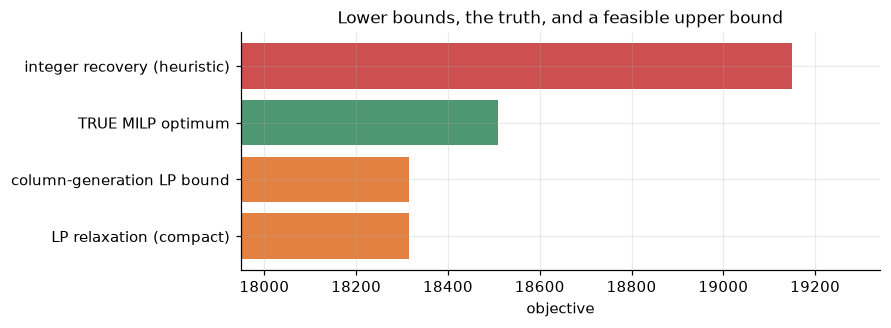

In [15]:
bounds = pd.DataFrame(
    {
        "value": {
            "LP relaxation (compact)": lp_record.objective,
            "column-generation LP bound": cg_record.objective,
            "TRUE MILP optimum": milp_record.objective,
            "integer recovery (heuristic)": recovery_record.objective,
        }
    }
)
bounds["vs MILP"] = bounds["value"] / milp_record.objective - 1
display(bounds.round(6))

heuristic_gap = (recovery_record.objective - milp_record.objective) / milp_record.objective
print(f"\nheuristic gap: {heuristic_gap:.3%}")
print(f"certified interval from column generation alone: "
      f"[{cg_record.objective:,.2f}, {recovery_record.objective:,.2f}]")
print(f"width: {recovery_record.objective - cg_record.objective:,.2f} "
      f"({(recovery_record.objective - cg_record.objective) / recovery_record.objective:.2%})")

fig, ax = plt.subplots(figsize=(7.5, 2.8))
order = ["LP relaxation (compact)", "column-generation LP bound",
         "TRUE MILP optimum", "integer recovery (heuristic)"]
colours = [COLORS["relaxed"], COLORS["relaxed"], COLORS["optimum"], COLORS["infeasible"]]
ax.barh(order, [bounds.loc[k, "value"] for k in order], color=colours, alpha=0.85)
ax.set_xlim(min(bounds["value"]) * 0.98, max(bounds["value"]) * 1.01)
ax.set_xlabel("objective")
ax.set_title("Lower bounds, the truth, and a feasible upper bound")
plt.show()

In [16]:
assert bounds is not None, "build the `bounds` table first"
assert bounds.loc["LP relaxation (compact)", "value"] <= (
    bounds.loc["column-generation LP bound", "value"] + 1e-4
), "Dantzig-Wolfe must be at least as strong as the LP relaxation"
assert bounds.loc["column-generation LP bound", "value"] <= (
    bounds.loc["TRUE MILP optimum", "value"] + 1e-4
), "the LP bound cannot exceed the integer optimum"
assert bounds.loc["integer recovery (heuristic)", "value"] >= (
    bounds.loc["TRUE MILP optimum", "value"] - 1e-6
), "a heuristic cannot beat the true optimum"
print("Checks passed: LP <= DW <= MILP <= heuristic.")

Checks passed: LP <= DW <= MILP <= heuristic.


#### Interpretation

**Why can column generation converge while the integer solution stays hard?**

In [17]:
print("ANSWER.")
print()
print("Column generation converged perfectly: it solved the LP over ALL columns")
print(f"to {cg_record.objective:,.4f}, proved by the absence of any negative reduced")
print(f"cost. The integer recovery came out at {recovery_record.objective:,.4f}, which is")
print(f"{heuristic_gap:.2%} above the true optimum of {milp_record.objective:,.4f}.")
print()
print("Nothing went wrong. The two are answers to different questions.")
print()
print("Column generation optimises over conv(X_g) -- the CONVEX HULL of each")
print("generator's schedules. The LP optimum is generally a fractional")
print("combination, and a fractional combination of schedules is not a schedule.")
print()
print("The recovery then searches only the columns that happened to be")
print("generated. Those columns were generated to be attractive AT THE LP")
print("PRICES, and the prices that matter for the integer problem are different.")
print("The schedule the integer optimum needs may simply never have been priced,")
print("because at no point in the run did it look attractive.")
print()
print("BRANCH-AND-PRICE fixes this by interleaving the two. At each")
print("branch-and-bound node it re-runs column generation with the branching")
print("constraints active, so columns are generated at the prices of THAT node.")
print("The subtlety, and the reason it is not a two-line change: branching on")
print("lambda directly destroys the pricing problem's structure (it forbids one")
print("specific schedule, which the subproblem cannot express), so one branches")
print("on the ORIGINAL variables instead -- for instance on whether generator g")
print("is on at time t -- which the pricing problem can absorb as a bound.")
print()
print("Meanwhile the honest report from column generation alone is an interval:")
print()
print(f"    {cg_record.objective:,.2f}  <=  z*  <=  {recovery_record.objective:,.2f}")
print()
print(f"and the true optimum {milp_record.objective:,.4f} does lie inside it. The width")
print("is what you do not know -- exactly the shape of every other bound in this")
print("course.")

ANSWER.

Column generation converged perfectly: it solved the LP over ALL columns
to 18,314.7619, proved by the absence of any negative reduced
cost. The integer recovery came out at 19,150.0000, which is
3.46% above the true optimum of 18,510.0000.

Nothing went wrong. The two are answers to different questions.

Column generation optimises over conv(X_g) -- the CONVEX HULL of each
generator's schedules. The LP optimum is generally a fractional
combination, and a fractional combination of schedules is not a schedule.

The recovery then searches only the columns that happened to be
generated. Those columns were generated to be attractive AT THE LP
PRICES, and the prices that matter for the integer problem are different.
The schedule the integer optimum needs may simply never have been priced,
because at no point in the run did it look attractive.

BRANCH-AND-PRICE fixes this by interleaving the two. At each
branch-and-bound node it re-runs column generation with the branching
constrain

## 8. Key takeaways

1. **A column is a whole pattern** — here, one generator's entire day.
2. **The pricing problem is an optimization problem**, over one generator's
   own constraints, and it is where the structure hides.
3. **Reduced cost is a profit calculation at the master's prices.** Non-negative
   everywhere means the LP is solved without enumeration.
4. **Artificial variables are how the method starts.** An infeasible master has
   no duals, so there is nothing to price with.
5. **Dantzig-Wolfe is at least as strong as the LP relaxation.** Here the two
   were equal — but *not* because of the integrality property, which two of
   the three subproblems measurably fail. Equality was a property of this
   instance, not of the formulation.
6. **Column generation solves an LP.** The integer answer needs
   branch-and-price; a restricted MILP is a heuristic, and here it was 3.5%
   off.

## Further reading

- Dantzig & Wolfe, "Decomposition principle for linear programs", *Operations
  Research* 8(1), 1960.
- Barnhart, Johnson, Nemhauser, Savelsbergh & Vance, "Branch-and-price: column
  generation for solving huge integer programs", *Operations Research* 46(3),
  1998.
- Lübbecke & Desrosiers, "Selected topics in column generation", *Operations
  Research* 53(6), 2005.
- Geoffrion, "Lagrangean relaxation for integer programming", *Mathematical
  Programming Study* 2, 1974 — the integrality-property result behind §5.

## Next

Tutorial 10 puts everything together on a realistic distribution grid, and
asks the question the whole course has been building to: **which formulation
does this decision actually need?**